# Desafio Final

## 1. Introdução

Este estudo tem como objetivo analisar o consumo de energia elétrica no Brasil ao longo dos anos, considerando as variações entre diferentes tipos de consumidores, estados e períodos. A partir dessa análise, busca-se compreender a evolução do consumo no país, identificar padrões regionais e temporais e avaliar possíveis impactos de políticas públicas e acontecimentos econômicos sobre o setor elétrico, contribuindo para uma visão mais ampla do comportamento energético brasileiro.

## 2. Preparação dos dados

### 2.1 Importação das bibliotecas

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import sys
sys.path.append('../')
from src.plots import barplot, lineplot, heatmap

### 2.2 Carregamento dos dados

In [2]:
energia_df = pd.read_csv('../data/consumo_energia_eletrica.csv')
est_rg_df = pd.read_csv('../data/estado_regiao.csv', sep=';', encoding='latin1')

### 2.3 Análise inicial

In [ ]:
#Visualizando os 5 primeiros dados
energia_df.head()

,ano,mes,sigla_uf,tipo_consumo,numero_consumidores,consumo
0,2004,1,TO,Total,NaN,65876
1,2004,1,BA,Total,NaN,1444451
2,2004,1,PR,Total,NaN,1596274
3,2004,1,RS,Total,NaN,1780912
4,2004,1,GO,Total,NaN,630624


In [ ]:
#Para uma analise mais detalhada dos dados utilizamos o seguinte comando
energia_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 39897 entries, 0 to 39896
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ano                  39897 non-null  int64  
 1   mes                  39897 non-null  int64  
 2   sigla_uf             39897 non-null  str    
 3   tipo_consumo         39897 non-null  str    
 4   numero_consumidores  26937 non-null  float64
 5   consumo              39897 non-null  int64  
dtypes: float64(1), int64(3), str(2)
memory usage: 1.8 MB


Podemos visualizar  que existe 39896 valores, porém apenas 26937 na coluna 'numero_consumidores', ou seja existe uma quantidade alta de valores faltantes.

### 2.4 Valores ausentes

In [ ]:
#Para verificar a quantidade desses valores de uma forma mais direta, utilizamos o comando abaixo.
energia_df.isnull().sum()

ano                    0
mes                    0
sigla_uf               0
tipo_consumo           0
numero_consumidores    0
consumo                0
dtype: int64

Verificamos então que existe 12960, valores nulos e dessa vez, iremos excluir as linhas com esses valores.

In [ ]:
#Agora excluindo as linhas com esses valores nulos
energia_df = energia_df.dropna(subset=['numero_consumidores']).copy()

Com isso, verificamos novamente e ja podemos perceber que ja não existem valores nulos

In [7]:
energia_df.isnull().sum()

ano                    0
mes                    0
sigla_uf               0
tipo_consumo           0
numero_consumidores    0
consumo                0
dtype: int64

### 2.5 Valores duplicados

In [ ]:
#Analisa a existencia de duplicatas
energia_df.duplicated().sum()

np.int64(1017)

Observamos que existem 1017 linhas identicas, para que isso não atrapalhe nossa analise, iremos deletar essas linhas

In [9]:
energia_df = energia_df.drop_duplicates()
energia_df.duplicated().sum()

np.int64(0)

Confirmamos que agora não existem mais duplicatas

---

Depois desse tratamento inical dos dados, verificamos novamente como ficou uma previa dos dados e sua estrutura

In [10]:
energia_df.head()

,ano,mes,sigla_uf,tipo_consumo,numero_consumidores,consumo
648,2004,1,RN,Outros,40857.0,69617
649,2004,1,SP,Outros,311650.0,937538
650,2004,1,MS,Outros,56881.0,67601
651,2004,1,SC,Outros,226165.0,209380
652,2004,1,RJ,Outros,70634.0,416128


In [11]:
energia_df.info()

<class 'pandas.DataFrame'>
Index: 25920 entries, 648 to 38879
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ano                  25920 non-null  int64  
 1   mes                  25920 non-null  int64  
 2   sigla_uf             25920 non-null  str    
 3   tipo_consumo         25920 non-null  str    
 4   numero_consumidores  25920 non-null  float64
 5   consumo              25920 non-null  int64  
dtypes: float64(1), int64(3), str(2)
memory usage: 1.4 MB


### 2.6 Integração das bases

Para fins de melhorar nossa análise, iremos integrar a base que contém os dados de estado e região, junto a base de consumo de energia.

In [12]:
est_rg_df = est_rg_df.rename(columns={'sigla':'sigla_uf'})

In [13]:
total_df = est_rg_df.merge(energia_df,on='sigla_uf', how='inner')
total_df = total_df.drop(columns=['id_estado', 'pais'])

In [14]:
total_df.head()

,sigla_uf,estado,regiao,ano,mes,tipo_consumo,numero_consumidores,consumo
0,AC,Acre,Norte,2004,1,Outros,9943.0,9428
1,AC,Acre,Norte,2004,2,Outros,10041.0,9189
2,AC,Acre,Norte,2004,3,Outros,10080.0,9586
3,AC,Acre,Norte,2004,4,Outros,10101.0,10355
4,AC,Acre,Norte,2004,5,Outros,10122.0,6205


In [15]:
total_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 25920 entries, 0 to 25919
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   sigla_uf             25920 non-null  str    
 1   estado               25920 non-null  str    
 2   regiao               25920 non-null  str    
 3   ano                  25920 non-null  int64  
 4   mes                  25920 non-null  int64  
 5   tipo_consumo         25920 non-null  str    
 6   numero_consumidores  25920 non-null  float64
 7   consumo              25920 non-null  int64  
dtypes: float64(1), int64(3), str(4)
memory usage: 1.6 MB


Conseguimos verificar que geramos um dataframe totalmente novo, utilizando os dados dos dois datasets, assim é possivel fazer uma análise mais completa, considerando os dados dos dois datasets.

## 3. Análise exploratória

### 3.1 Estatísticas descritivas

**Objetivo:** resumir as medidas de tendência central, dispersão e posição das variáveis numéricas.

In [16]:
total_df.describe().round(2)

,ano,mes,numero_consumidores,consumo
count,25920.00,25920.00,25920.00,25920.00
mean,2013.50,6.50,682303.38,339170.90
std,5.77,3.45,1839311.69,603642.75
min,2004.00,1.00,52.00,354.00
25%,2008.75,3.75,18956.50,61545.50
50%,2013.50,6.50,108174.50,136754.50
75%,2018.25,9.25,442412.00,361651.75
max,2023.00,12.00,19201264.00,4849895.00


**Insight:** A análise descritiva indica grande dispersão tanto no número de consumidores quanto no consumo de energia elétrica. Em ambas as variáveis, a média é significativamente superior à mediana, sugerindo distribuições assimétricas à direita. Além disso, os valores máximos estão muito acima do terceiro quartil, indicando a presença de observações extremas que devem ser investigadas por estado, região e tipo de consumo.

---

### 3.2 Distribuição das variáveis

**Objetivo:** examinar a distribuição do número de consumidores e do consumo de energia elétrica.

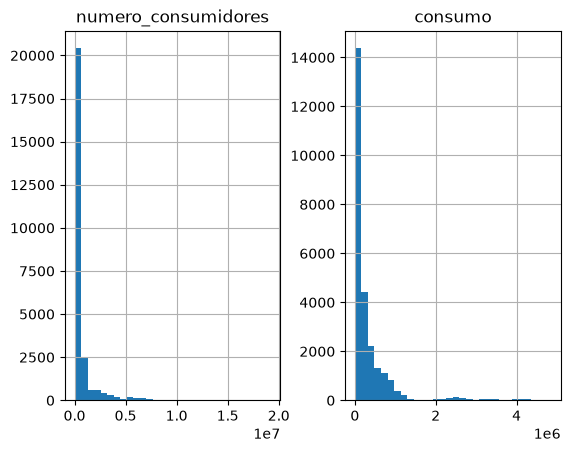

In [17]:
energia_df[['numero_consumidores', 'consumo']].hist(bins=30)
plt.show()

**Insight:** Com o histograma abaixo podemos ver essa assimetria, existem muitos valores baixos e poucos valores altos.

---

### 3.3 Correlações

**Objetivo:** examinar as correlações entre as variáveis numéricas.

In [18]:
num_df = total_df.select_dtypes('number')

In [19]:
num_df.corr().round(3)

,ano,mes,numero_consumidores,consumo
ano,1.000,-0.000,0.058,0.069
mes,-0.000,1.000,0.003,0.004
numero_consumidores,0.058,0.003,1.000,0.445
consumo,0.069,0.004,0.445,1.000


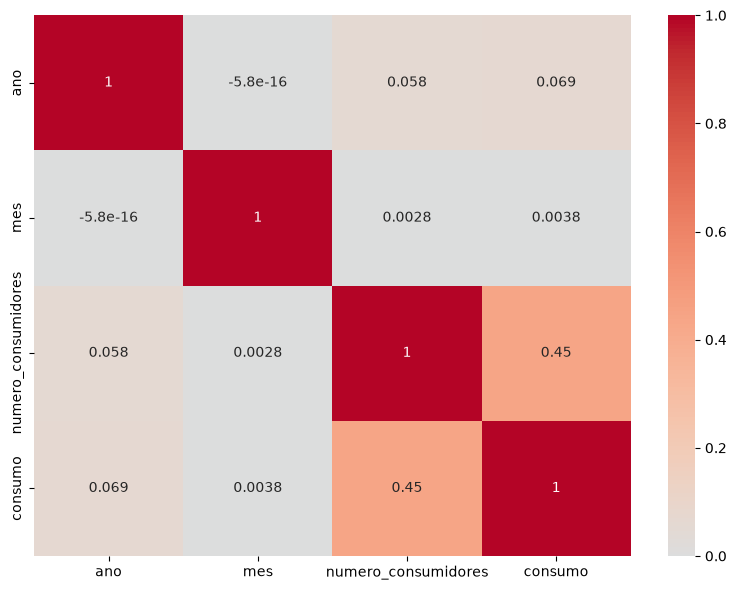

In [20]:
heatmap(num_df)

**Insight:** a maior correlação observada ocorre entre `numero_consumidores` e `consumo`, com valor aproximado de 0,45, indicando uma relação positiva moderada. As variáveis `ano` e `mes` apresentam correlações lineares muito baixas com o consumo e com o número de consumidores. Isso indica que essas variáveis temporais não possuem uma relação linear simples com as demais, sendo mais adequadas para análises específicas de tendência e sazonalidade.

---

### 3.4 Análises temporais

#### 3.4.1 Evolução do consumo de energia elétrica ao longo dos anos

**Objetivo:** analisar a evolução do consumo total de energia elétrica entre 2004 e 2023, identificando tendências de crescimento, quedas e possíveis mudanças de comportamento ao longo do período.

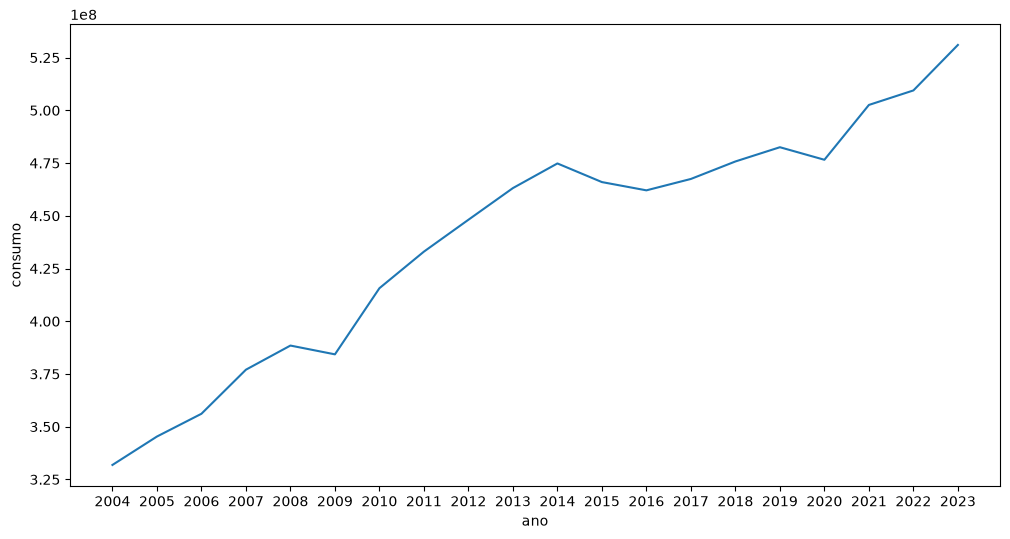

In [21]:
lineplot(total_df, 'ano', 'consumo')

**Insight:** observa-se uma tendência geral de crescimento do consumo de energia elétrica entre 2004 e 2023. Apesar desse crescimento, existem alguns períodos de redução ou estabilidade, como entre 2008 e 2009, entre 2014 e 2016 e entre 2019 e 2020. A partir de 2020, o consumo volta a crescer de forma mais acentuada, atingindo o maior valor da série em 2023.

---

#### 3.4.2 Evolução anual do consumo de energia por região

**Objetivo:** comparar a evolução do consumo de energia elétrica entre as regiões brasileiras ao longo do período analisado, identificando diferenças de magnitude e tendência.

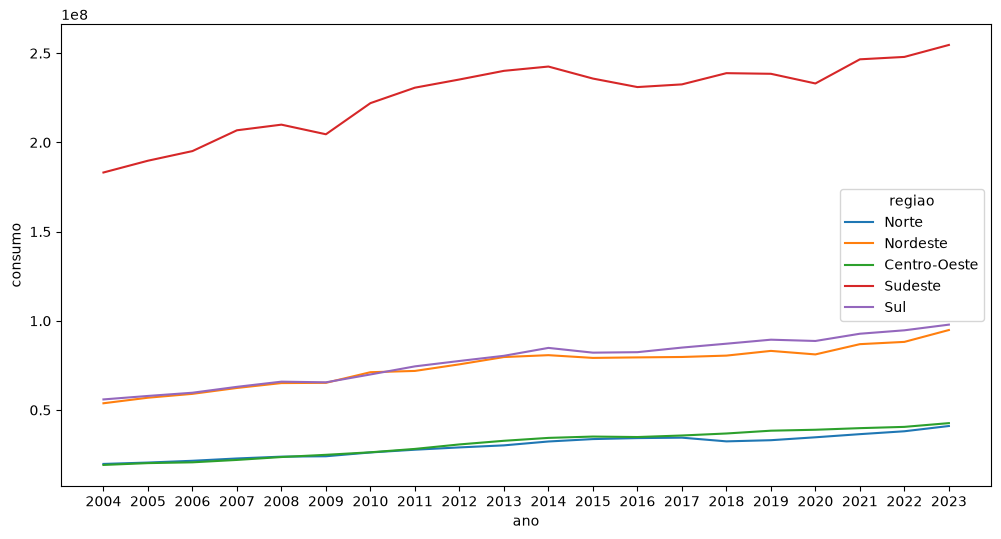

In [22]:
lineplot(total_df, 'ano', 'consumo', hue='regiao')

**Insight:** a região Sudeste apresenta, durante todo o período, o maior consumo de energia elétrica entre as regiões brasileiras, com ampla diferença em relação às demais. Sul e Nordeste aparecem em uma faixa intermediária e com comportamento relativamente próximo ao longo dos anos. Norte e Centro-Oeste apresentam os menores níveis de consumo, embora também mostrem tendência geral de crescimento. Observam-se ainda algumas oscilações pontuais, principalmente no Sudeste, mas sem alterar a tendência de crescimento no longo prazo.

---

#### 3.4.3 Consumo mensal de energia elétrica

**Objetivo:** analisar como o consumo de energia varia entre os meses, buscando identificar possíveis padrões sazonais ao longo do ano.

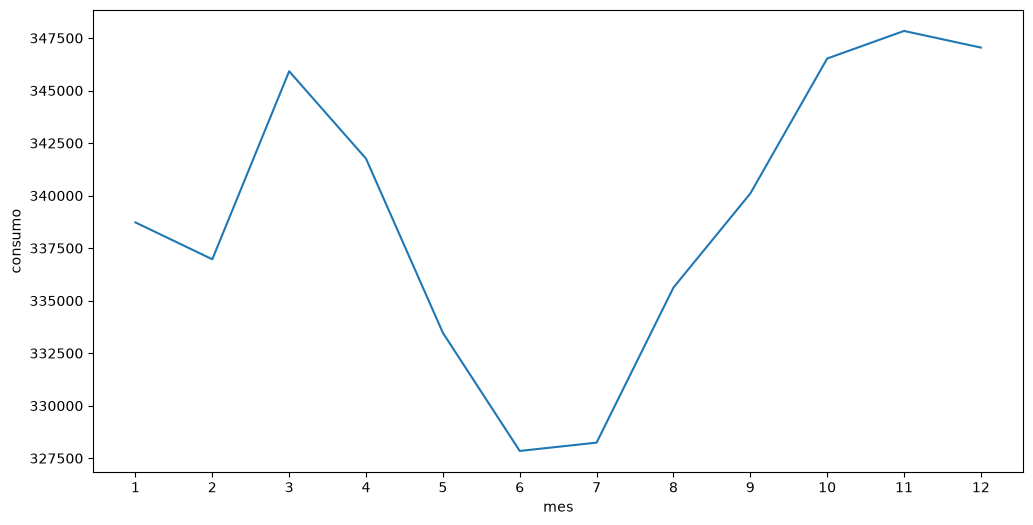

In [23]:
lineplot(total_df, 'mes', 'consumo', 'mean')

**Insight:** o consumo médio apresenta variação ao longo dos meses. Observa-se uma redução mais acentuada entre abril e junho, com o menor nível ocorrendo em junho. A partir de julho, o consumo volta a crescer de forma consistente, atingindo seus maiores valores entre outubro e dezembro. Esse comportamento sugere a presença de um padrão sazonal no consumo de energia elétrica.

---

#### 3.4.4 Consumo mensal de energia em 2020 por tipo de consumo

**Objetivo:** comparar o consumo entre os meses de 2020 e os diferentes tipos de consumo.

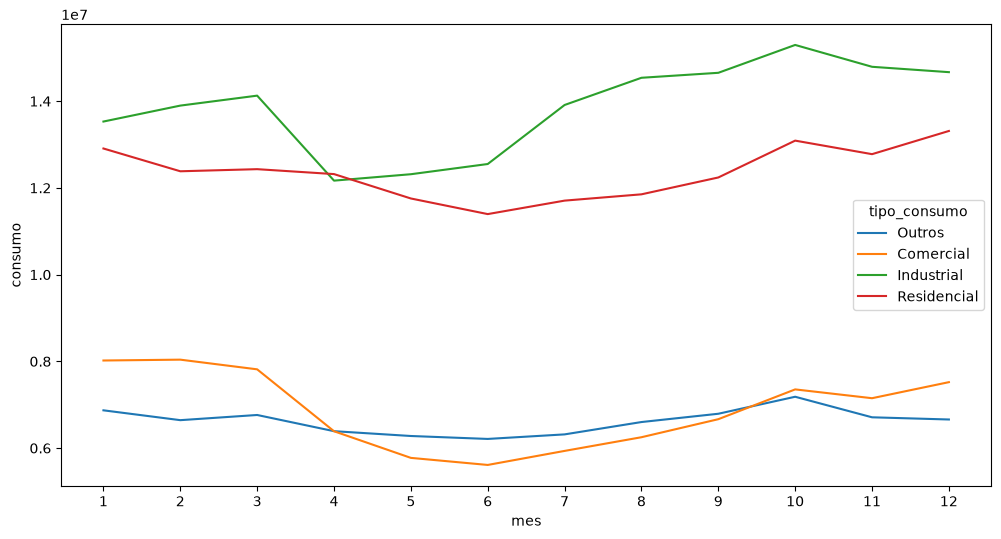

In [24]:
lineplot(total_df[total_df['ano'] == 2020], 'mes', 'consumo', hue='tipo_consumo')

**Insight:** observa-se uma redução do consumo em diferentes categorias durante os primeiros meses de 2020, principalmente nos segmentos industrial e comercial. A partir do meio do ano, esses segmentos apresentam recuperação gradual, com crescimento mais evidente no segundo semestre. O consumo residencial também apresenta queda até aproximadamente junho, seguida de retomada nos meses seguintes. O comportamento indica que 2020 apresentou alterações relevantes no padrão mensal de consumo entre as categorias.

**Insight:** a preencher após a análise dos resultados.

---

#### 3.4.5 Consumo de 2020 em comparação com a média de 2017 a 2019

**Objetivo:** comparar o consumo nacional mensal de 2020 com a média dos totais mensais de 2017, 2018 e 2019, separadamente por tipo de consumo.

**1. Somar o consumo dos estados**

Cada linha passa a mostrar o consumo nacional de uma categoria em determinado mês e ano.

In [25]:
consumo_mensal = total_df.groupby(['ano', 'mes', 'tipo_consumo'], as_index=False)['consumo'].sum()
consumo_mensal.head(8)

,ano,mes,tipo_consumo,consumo
0,2004,1,Comercial,4244827
1,2004,1,Industrial,12008843
2,2004,1,Outros,3943980
3,2004,1,Residencial,6780672
4,2004,2,Comercial,4147264
5,2004,2,Industrial,12141405
6,2004,2,Outros,3790231
7,2004,2,Residencial,6429231


**2. Selecionar os três anos de referência**

Usamos apenas 2017, 2018 e 2019 para construir a média de comparação.

In [26]:
anos_anteriores = consumo_mensal[consumo_mensal['ano'].between(2017, 2019)]
anos_anteriores.head(8)

,ano,mes,tipo_consumo,consumo
624,2017,1,Comercial,7778453
625,2017,1,Industrial,13155121
626,2017,1,Outros,6529951
627,2017,1,Residencial,11905635
628,2017,2,Comercial,7683653
629,2017,2,Industrial,13456483
630,2017,2,Outros,6326579
631,2017,2,Residencial,11369668


**3. Calcular a média histórica**

Calculamos a média de cada mês e categoria nesses três anos. Por exemplo, os três janeiros industriais viram um único valor. A coluna `serie` identifica essa linha na legenda do gráfico.

In [27]:
media_historica = anos_anteriores.groupby(['mes', 'tipo_consumo'], as_index=False)['consumo'].mean()
media_historica['serie'] = 'Média de 2017 a 2019'
media_historica.head(8)

,mes,tipo_consumo,consumo,serie
0,1,Comercial,7.838434e+06,Média de 2017 a 2019
1,1,Industrial,1.364275e+07,Média de 2017 a 2019
2,1,Outros,6.608817e+06,Média de 2017 a 2019
3,1,Residencial,1.226698e+07,Média de 2017 a 2019
4,2,Comercial,7.821732e+06,Média de 2017 a 2019
5,2,Industrial,1.350725e+07,Média de 2017 a 2019
6,2,Outros,6.509057e+06,Média de 2017 a 2019
7,2,Residencial,1.188507e+07,Média de 2017 a 2019


**4. Separar os valores de 2020**

Aqui mantemos os totais reais de cada mês de 2020 e identificamos a série.

In [28]:
consumo_2020 = consumo_mensal[consumo_mensal['ano'] == 2020].copy()
consumo_2020['serie'] = '2020'
consumo_2020.head(8)

,ano,mes,tipo_consumo,consumo,serie
768,2020,1,Comercial,8019682,2020
769,2020,1,Industrial,13530222,2020
770,2020,1,Outros,6870754,2020
771,2020,1,Residencial,12908496,2020
772,2020,2,Comercial,8039213,2020
773,2020,2,Industrial,13897726,2020
774,2020,2,Outros,6643933,2020
775,2020,2,Residencial,12383219,2020


**5. Reunir as duas séries**

Juntamos a média histórica e os valores de 2020 na mesma tabela. Abaixo, mostramos janeiro para conferir as duas séries de cada categoria.

In [29]:
comparacao = pd.concat([media_historica, consumo_2020], ignore_index=True)
comparacao[comparacao['mes'] == 1][['mes', 'tipo_consumo', 'consumo', 'serie']]

,mes,tipo_consumo,consumo,serie
0,1,Comercial,7.838434e+06,Média de 2017 a 2019
1,1,Industrial,1.364275e+07,Média de 2017 a 2019
2,1,Outros,6.608817e+06,Média de 2017 a 2019
3,1,Residencial,1.226698e+07,Média de 2017 a 2019
48,1,Comercial,8.019682e+06,2020
49,1,Industrial,1.353022e+07,2020
50,1,Outros,6.870754e+06,2020
51,1,Residencial,1.290850e+07,2020


**6. Gerar um gráfico para cada categoria**

O `for` separa as categorias e chama nossa função `lineplot` para cada uma. As duas linhas comparam 2020 com a média de 2017 a 2019. Usamos `estimator=None` porque os valores já estão calculados.

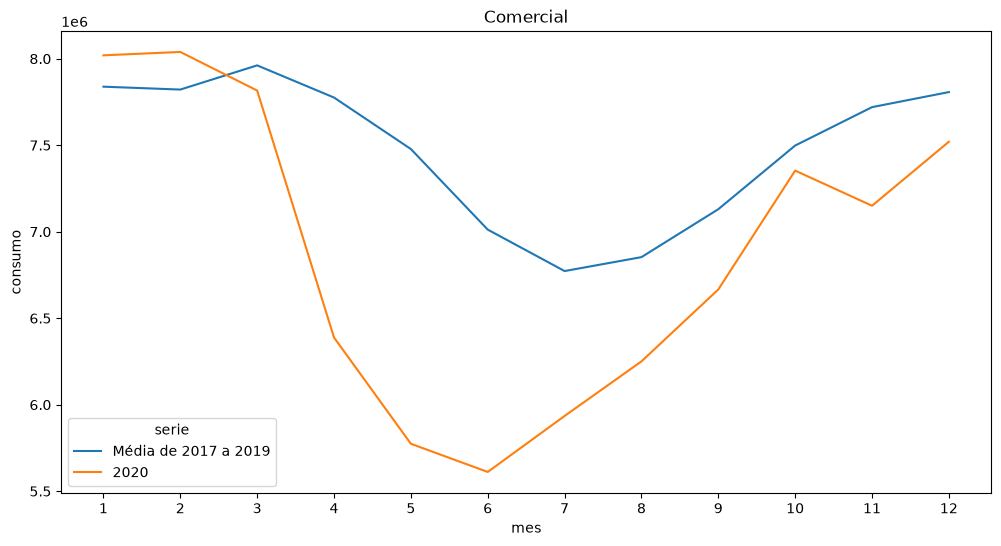

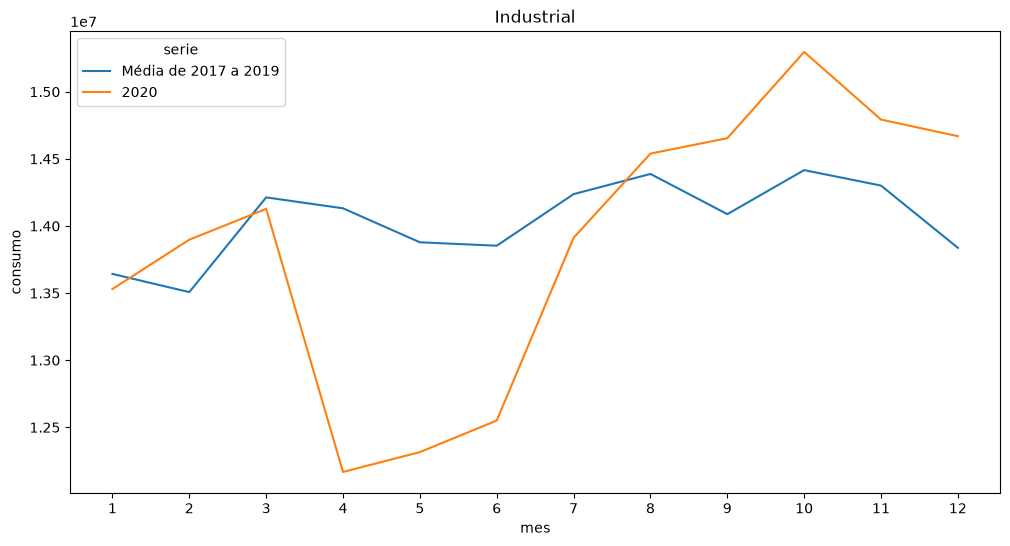

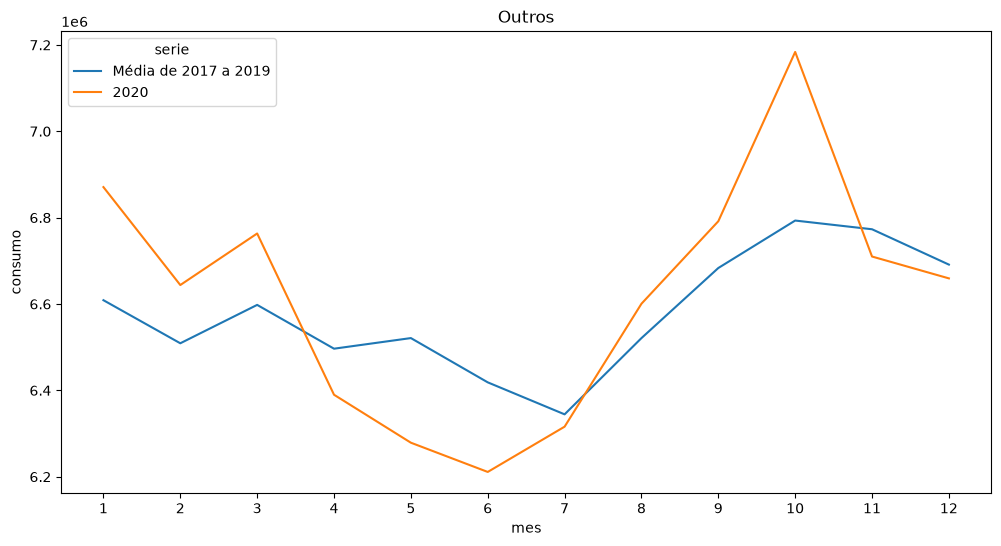

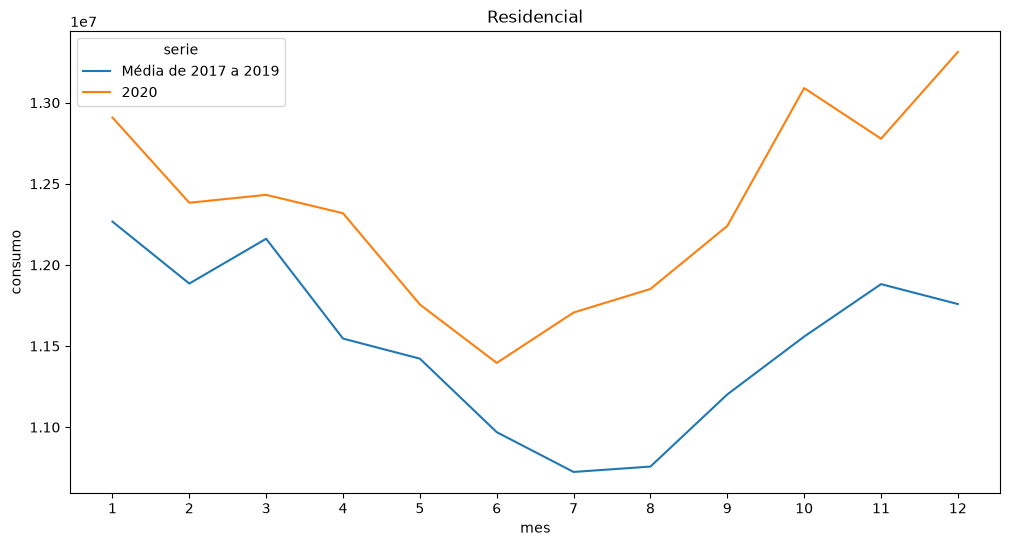

In [30]:
for tipo, dados in comparacao.groupby('tipo_consumo'):
    lineplot(dados, 'mes', 'consumo', estimator=None, hue='serie', title=tipo)

**Insight:** em comparação com a média de 2017 a 2019, o ano de 2020 apresentou alterações relevantes no comportamento mensal do consumo de energia, principalmente nos segmentos comercial e industrial. O consumo comercial sofreu uma queda acentuada entre março e junho, permanecendo abaixo do padrão histórico durante boa parte do ano. No setor industrial, a redução foi ainda mais evidente a partir de abril, seguida de recuperação ao longo do segundo semestre, chegando a superar a média histórica nos últimos meses. Já o consumo residencial permaneceu acima da média de 2017 a 2019 durante praticamente todo o ano, com aumento mais pronunciado a partir do segundo semestre. A categoria "Outros" apresentou diferenças menores, mantendo comportamento relativamente próximo ao padrão histórico, apesar de algumas oscilações. Esses resultados indicam que 2020 apresentou um padrão de consumo distinto dos anos imediatamente anteriores, com impactos diferentes entre os tipos de consumo.

---

#### 3.4.6 Crescimento percentual do consumo por região

**Objetivo:** comparar o crescimento percentual do consumo regional entre 2004 e 2023, primeiro e último ano com 12 meses completos em todas as regiões.

O cálculo utilizado é `(consumo final / consumo inicial - 1) × 100`.

In [31]:
# Consumo total de cada região nos dois anos
consumo_2004 = total_df[total_df['ano'] == 2004].groupby('regiao')['consumo'].sum()
consumo_2023 = total_df[total_df['ano'] == 2023].groupby('regiao')['consumo'].sum()

# Crescimento percentual entre 2004 e 2023
crescimento = (consumo_2023 / consumo_2004 - 1) * 100
crescimento_regiao = crescimento.reset_index(name='Crescimento (%)')


In [32]:
crescimento_regiao.round(1)

,regiao,Crescimento (%)
0,Centro-Oeste,121.9
1,Nordeste,76.3
2,Norte,107.4
3,Sudeste,39.0
4,Sul,74.9


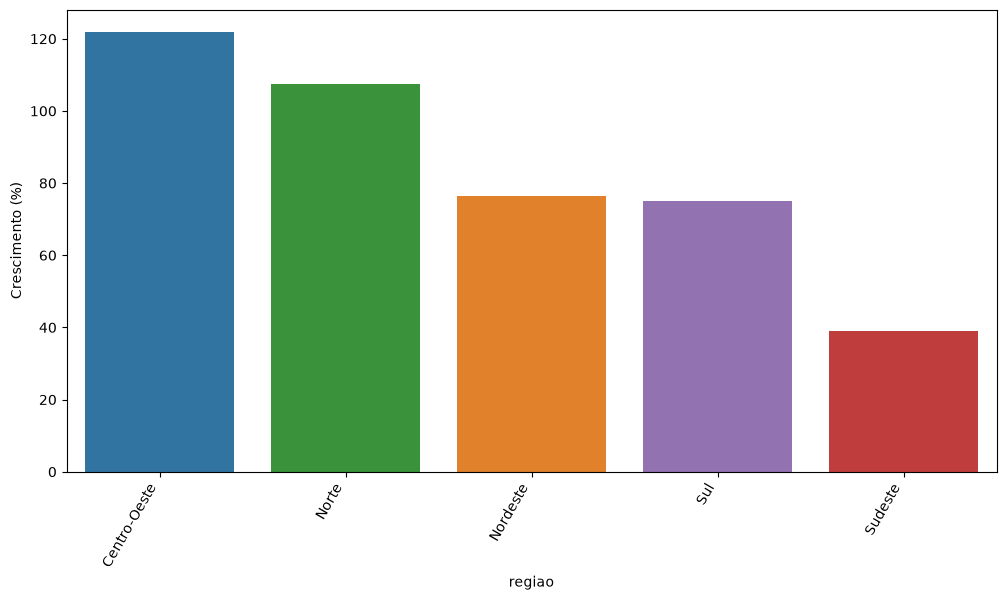

In [33]:
barplot(crescimento_regiao, 'regiao', 'Crescimento (%)', hue='regiao')

**Insight:** entre 2004 e 2023, todas as regiões apresentaram crescimento do consumo. O Centro-Oeste teve a maior variação percentual (121,9%), seguido pelo Norte (107,4%), Nordeste (76,3%), Sul (74,9%) e Sudeste (39,0%). Centro-Oeste e Norte mais que dobraram o consumo no período. Esses percentuais representam o crescimento acumulado entre os dois anos, não uma taxa anual nem o volume absoluto consumido.

---

#### 3.4.7 Participação dos tipos de consumo ao longo dos anos

**Objetivo:** analisar como a participação de cada tipo de consumo no total nacional mudou entre 2004 e 2023.

**1. Somar o consumo por ano e categoria**

Somamos os estados e os meses. Cada linha representa o consumo nacional de uma categoria em um ano.

In [34]:
consumo_por_tipo = total_df.groupby(['ano', 'tipo_consumo'], as_index=False)['consumo'].sum()
consumo_por_tipo.head(8)

,ano,tipo_consumo,consumo
0,2004,Comercial,49685771
1,2004,Industrial,156320559
2,2004,Outros,47388383
3,2004,Residencial,78469994
4,2005,Comercial,53034420
5,2005,Industrial,159662368
6,2005,Outros,49994810
7,2005,Residencial,82644121


**2. Calcular o consumo total de cada ano**

Somamos as categorias para obter o total nacional usado como referência.

In [35]:
total_por_ano = consumo_por_tipo.groupby('ano', as_index=False)['consumo'].sum()
total_por_ano = total_por_ano.rename(columns={'consumo': 'consumo_total'})
total_por_ano.head()

,ano,consumo_total
0,2004,331864707
1,2005,345335719
2,2006,356128761
3,2007,377030014
4,2008,388472375


**3. Juntar os valores pelo ano**

Adicionamos o total anual ao lado do consumo de cada categoria.

In [36]:
participacao = consumo_por_tipo.merge(total_por_ano, on='ano')
participacao.head(8)

,ano,tipo_consumo,consumo,consumo_total
0,2004,Comercial,49685771,331864707
1,2004,Industrial,156320559,331864707
2,2004,Outros,47388383,331864707
3,2004,Residencial,78469994,331864707
4,2005,Comercial,53034420,345335719
5,2005,Industrial,159662368,345335719
6,2005,Outros,49994810,345335719
7,2005,Residencial,82644121,345335719


**4. Calcular a participação percentual**

Dividimos o consumo da categoria pelo total do mesmo ano e multiplicamos por 100. A tabela mostra os percentuais por ano; antes do arredondamento, cada linha deve somar 100%.

In [37]:
participacao['Participação (%)'] = participacao['consumo'] / participacao['consumo_total'] * 100
participacao.pivot(index='ano', columns='tipo_consumo', values='Participação (%)').round(1)

tipo_consumo,Comercial,Industrial,Outros,Residencial
ano,,,,
2004,15.0,47.1,14.3,23.6
2005,15.4,46.2,14.5,23.9
2006,15.5,45.8,14.5,24.1
2007,15.6,46.2,14.4,23.8
2008,15.9,45.3,14.4,24.4
2009,17.0,42.1,14.7,26.2
2010,16.6,43.2,14.4,25.8
2011,17.0,42.4,14.8,25.9
2012,17.7,40.9,15.1,26.3


**5. Comparar a evolução das categorias**

Cada linha mostra como a participação de uma categoria mudou ao longo dos anos.

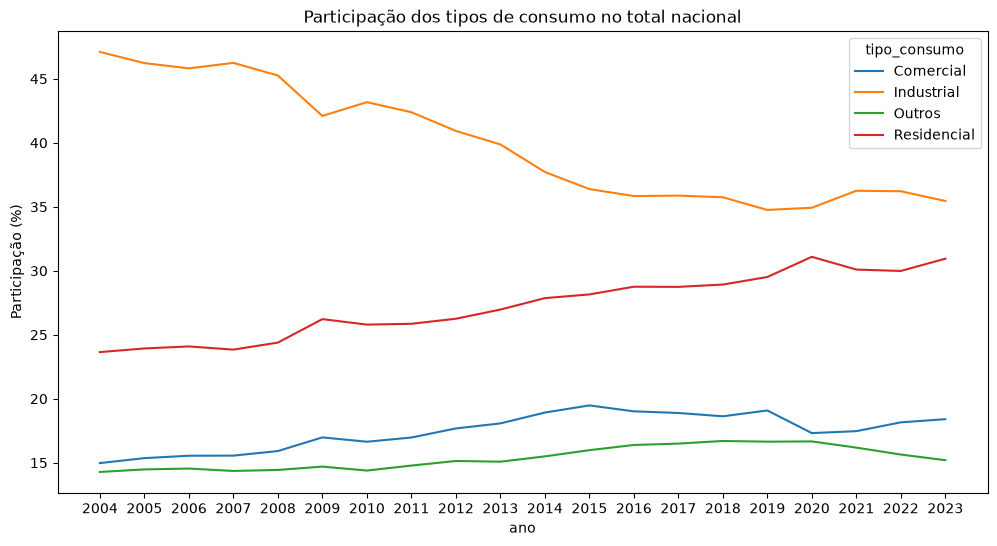

In [38]:
lineplot(participacao, 'ano', 'Participação (%)', estimator=None, hue='tipo_consumo', title='Participação dos tipos de consumo no total nacional')

**Insight:** em 2004, a indústria representava 47,1% do consumo de energia do país. Em 2023, essa parcela caiu para 35,5%. Já o consumo residencial passou de 23,6% para 30,9%, aumentando sua participação no total. As categorias comercial e outros também aumentaram sua participação. Isso não significa que a indústria consumiu menos energia, mas que passou a representar uma parte menor do consumo total do país.

---

### 3.5 Análises por categoria

#### 3.5.1 Consumo total de energia por região

**Objetivo:** comparar o consumo total de energia elétrica entre as regiões brasileiras ao longo de todo o período analisado.

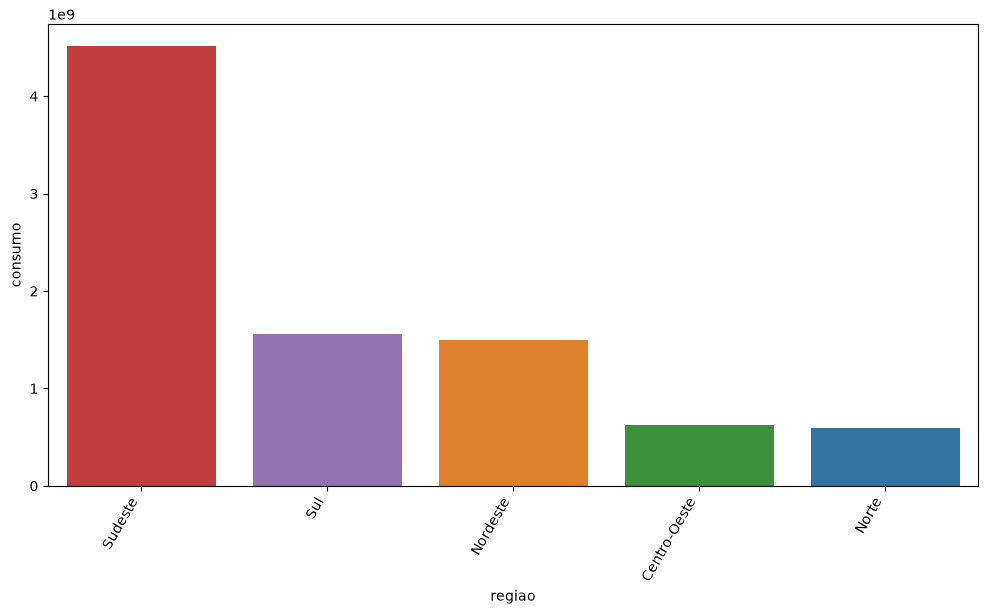

In [39]:
barplot(total_df, 'regiao', 'consumo', hue='regiao')

**Insight:** a região Sudeste apresenta, com ampla diferença, o maior consumo acumulado de energia elétrica no período analisado. Sul e Nordeste aparecem em níveis intermediários, enquanto Norte e Centro-Oeste apresentam os menores valores de consumo total. Esse resultado evidencia uma forte concentração regional do consumo de energia no país.

---

#### 3.5.2 Consumo de energia por região e tipo de consumo

**Objetivo:** comparar o consumo de energia elétrica entre as regiões brasileiras, considerando também os diferentes tipos de consumo.

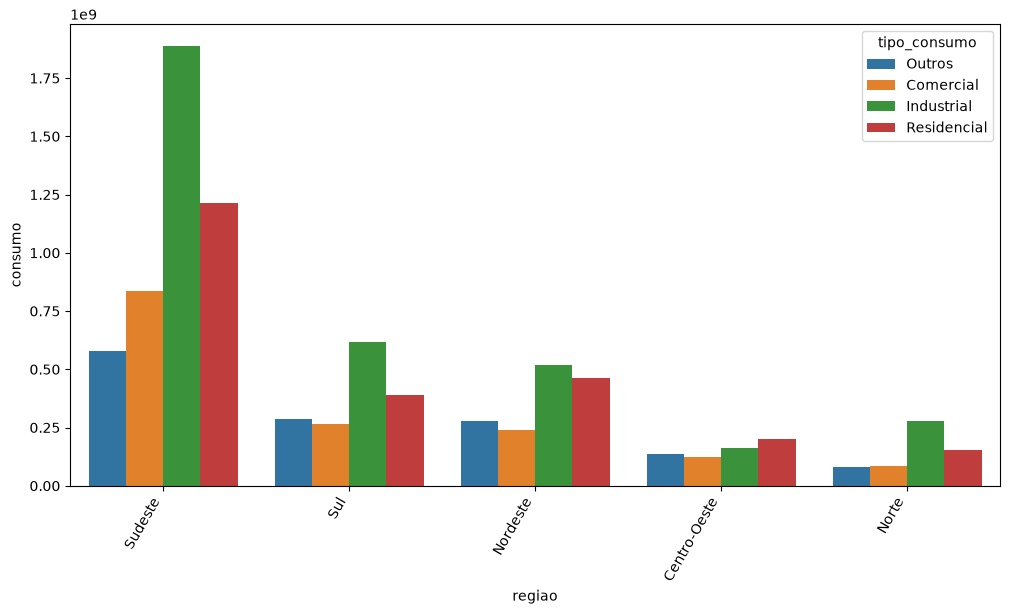

In [40]:
barplot(total_df, 'regiao', 'consumo', hue='tipo_consumo')

**Insight:** o consumo industrial se destaca como o maior entre os tipos de consumo na maior parte das regiões, especialmente no Sudeste, onde apresenta ampla diferença em relação às demais categorias. O consumo residencial também possui participação elevada, principalmente nas regiões Sudeste, Nordeste e Sul. Já as categorias comercial e outros apresentam valores menores em todas as regiões. O gráfico reforça ainda a predominância do Sudeste no consumo total de energia, independentemente do tipo de consumidor.

---

#### 3.5.3 Consumo total de energia por estado

**Objetivo:** comparar o consumo total de energia elétrica entre os estados brasileiros, identificando os estados com maior e menor consumo acumulado no período analisado.

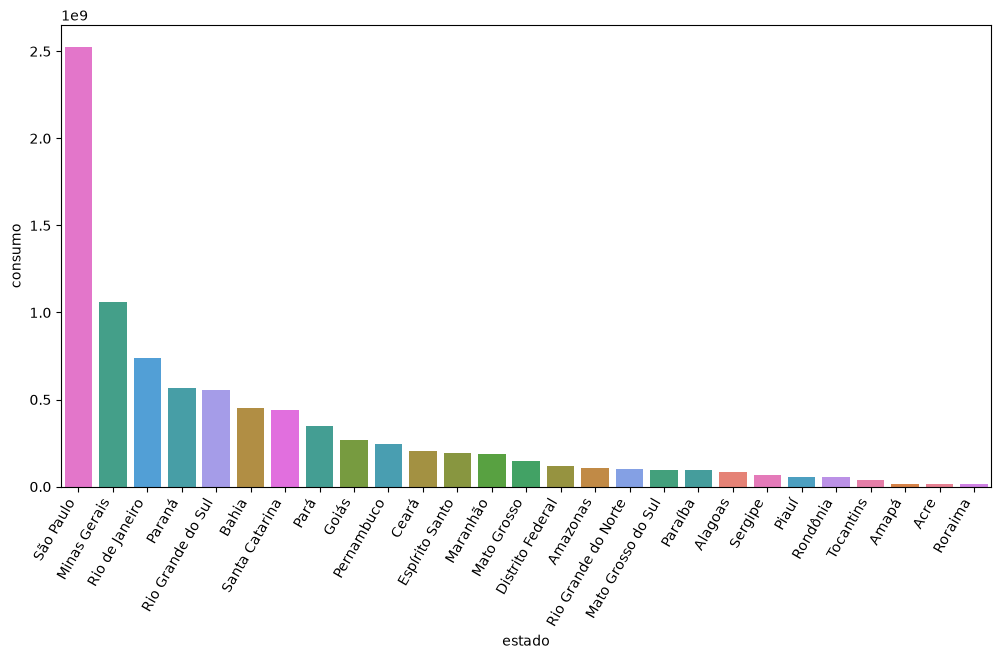

In [41]:
barplot(total_df, 'estado', 'consumo', hue='estado')

**Insight:** São Paulo apresenta, com ampla diferença, o maior consumo acumulado de energia elétrica entre os estados brasileiros. Minas Gerais e Rio de Janeiro aparecem em seguida, enquanto estados como Roraima, Acre e Amapá apresentam os menores valores. A diferença entre os estados evidencia uma forte concentração do consumo em alguns mercados estaduais.

---

#### 3.5.4 Média do número de consumidores por tipo de consumo e região

**Objetivo:** comparar a média do número de consumidores dos registros por tipo de consumo e região.

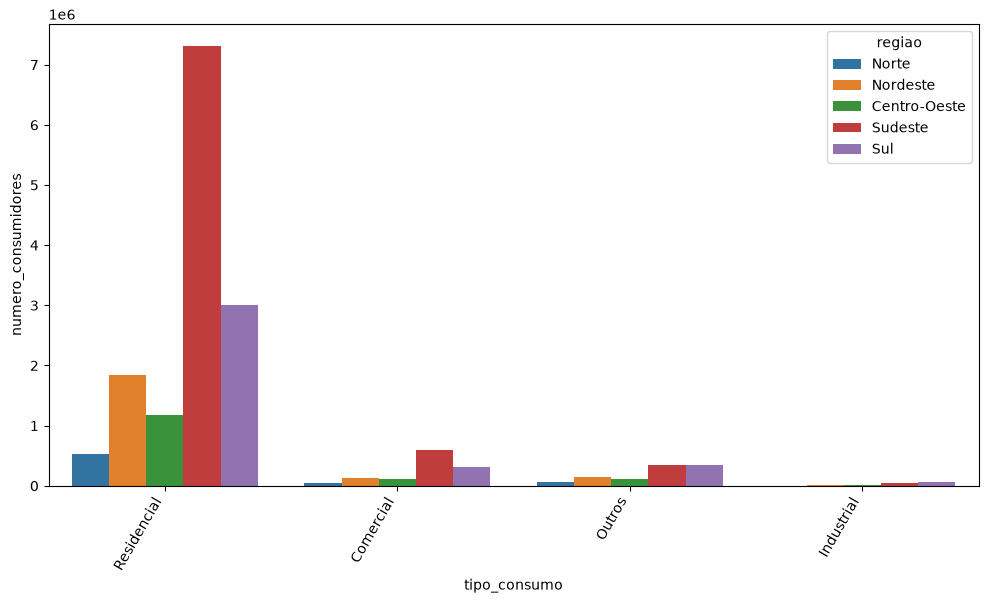

In [42]:
barplot(total_df, 'tipo_consumo', 'numero_consumidores', hue='regiao', estimator='mean')

**Insight:** a categoria residencial apresenta a maior média de consumidores em todas as regiões, enquanto a industrial apresenta a menor. O Sudeste se destaca nas categorias residencial, comercial e outros; na categoria industrial, a maior média ocorre no Sul. O Norte apresenta as menores médias em todas as categorias. Esses valores representam a média dos registros estaduais mensais ao longo do período, e não o total de consumidores de cada região.

---

### 3.6 Relações entre variáveis

#### 3.6.1 Relação entre número de consumidores e consumo de energia

**Objetivo:** analisar a relação entre o número de consumidores e o consumo de energia elétrica, verificando como essa relação varia entre os diferentes tipos de consumo.

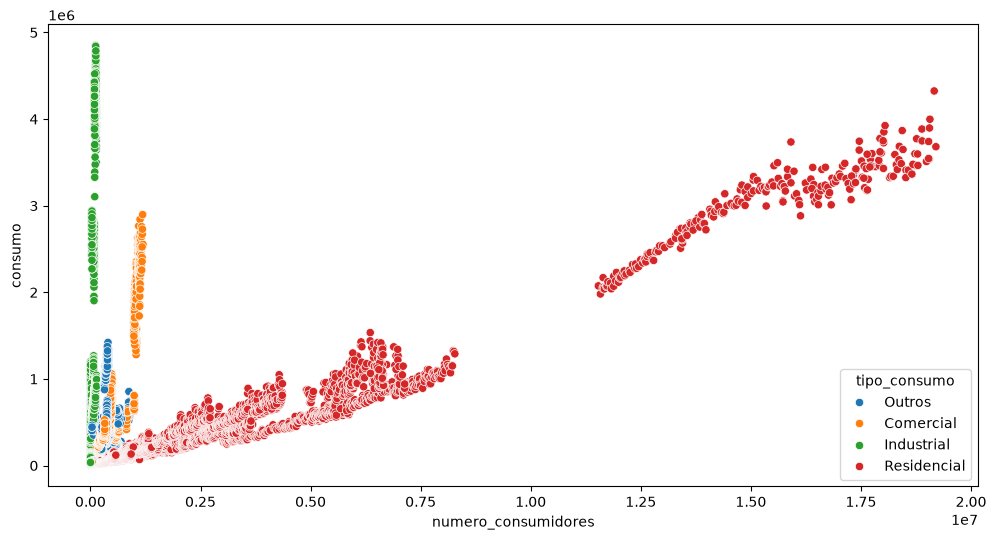

In [43]:
plt.figure(figsize=(12, 6))

sns.scatterplot(
    data=total_df,
    x='numero_consumidores',
    y='consumo',
    hue='tipo_consumo'
)

plt.show()

**Insight:** observa-se uma relação positiva entre número de consumidores e consumo de energia, principalmente no segmento residencial. Entretanto, essa relação varia significativamente entre os tipos de consumo. O setor industrial apresenta níveis elevados de consumo mesmo com um número relativamente pequeno de consumidores, enquanto o setor residencial concentra grande quantidade de consumidores e também apresenta crescimento do consumo à medida que esse número aumenta. Esse comportamento indica que diferentes categorias possuem perfis de consumo distintos.

---

#### 3.6.2 Consumo médio mensal por consumidor e tipo de consumo

**Objetivo:** comparar o consumo médio mensal por consumidor entre as categorias em 2023. Primeiro, dividimos o consumo nacional pelo número de consumidores de cada mês e categoria; depois, calculamos a média dos 12 indicadores mensais.

O indicador mantém a unidade original da coluna `consumo`, por consumidor.

**1. Selecionar 2023**

Filtramos os dados para trabalhar apenas com o ano escolhido. A tabela mostra os primeiros registros.

In [44]:
dados_2023 = total_df[total_df['ano'] == 2023]
dados_2023.head()

,sigla_uf,estado,regiao,ano,mes,tipo_consumo,numero_consumidores,consumo
912,AC,Acre,Norte,2023,1,Outros,23592.0,22904
913,AC,Acre,Norte,2023,2,Outros,23616.0,20623
914,AC,Acre,Norte,2023,3,Outros,23734.0,21507
915,AC,Acre,Norte,2023,4,Outros,23724.0,21961
916,AC,Acre,Norte,2023,5,Outros,23677.0,23308


**2. Somar os estados por mês e categoria**

Cada linha passa a representar o total nacional de consumo e de consumidores de uma categoria em um mês. Veja os dois primeiros meses:

In [45]:
mensal = dados_2023.groupby(['mes', 'tipo_consumo'], as_index=False)[['consumo', 'numero_consumidores']].sum()
mensal.head(8)

,mes,tipo_consumo,consumo,numero_consumidores
0,1,Comercial,8078496,6105236.0
1,1,Industrial,14941957,458884.0
2,1,Outros,6482904,5097837.0
3,1,Residencial,13310736,79108671.0
4,2,Comercial,8173047,6143851.0
5,2,Industrial,14596051,461942.0
6,2,Outros,6448002,5119810.0
7,2,Residencial,13680903,79566428.0


**3. Calcular o consumo por consumidor**

Dividimos o consumo pelo número de consumidores em cada linha. O resultado aparece na nova coluna `consumo_por_consumidor`.

In [46]:
mensal['consumo_por_consumidor'] = mensal['consumo'] / mensal['numero_consumidores']
mensal.head(8)

,mes,tipo_consumo,consumo,numero_consumidores,consumo_por_consumidor
0,1,Comercial,8078496,6105236.0,1.323208
1,1,Industrial,14941957,458884.0,32.561512
2,1,Outros,6482904,5097837.0,1.271697
3,1,Residencial,13310736,79108671.0,0.168259
4,2,Comercial,8173047,6143851.0,1.330281
5,2,Industrial,14596051,461942.0,31.597151
6,2,Outros,6448002,5119810.0,1.259422
7,2,Residencial,13680903,79566428.0,0.171943


**4. Calcular a média dos 12 meses**

Agora calculamos a média do indicador mensal para cada categoria.

In [47]:
media_por_consumidor = mensal.groupby('tipo_consumo', as_index=False)['consumo_por_consumidor'].mean()
media_por_consumidor.round(3)

,tipo_consumo,consumo_por_consumidor
0,Comercial,1.325
1,Industrial,33.994
2,Outros,1.343
3,Residencial,0.171


**5. Comparar as categorias no gráfico**

Usamos os valores da tabela anterior para gerar as barras.

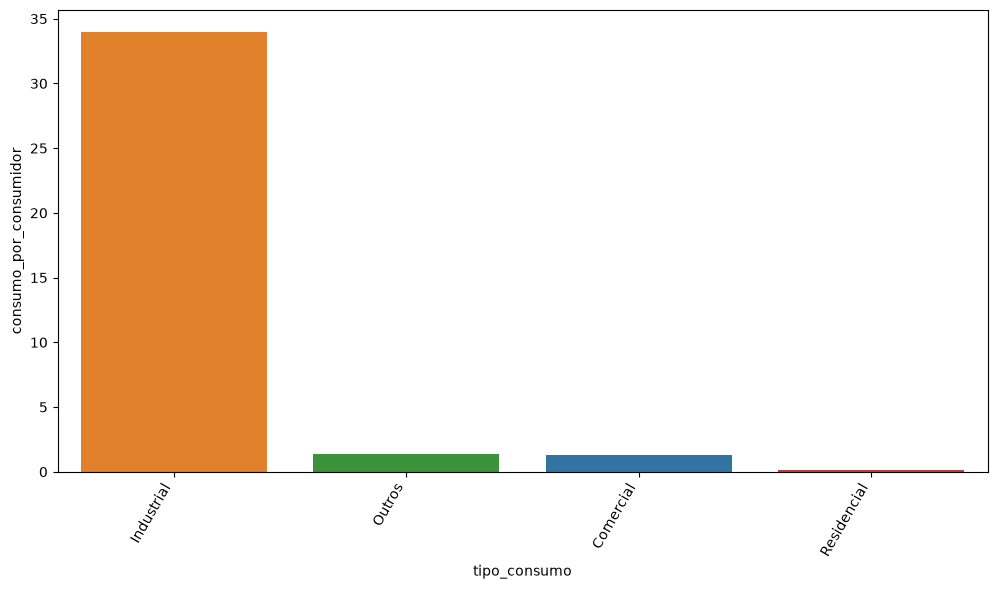

In [48]:
barplot(media_por_consumidor, 'tipo_consumo', 'consumo_por_consumidor', hue='tipo_consumo')

**Insight:** em 2023, a categoria industrial apresentou o maior consumo médio mensal por consumidor (33,994), seguida por outros (1,343), comercial (1,325) e residencial (0,171), na unidade original de consumo por consumidor. As categorias comercial e outros apresentaram valores próximos, enquanto a industrial ficou muito acima das demais. O resultado quantifica as diferenças entre categorias observadas no gráfico de dispersão, sem indicar que todos os consumidores de uma categoria tenham o mesmo consumo.

---

## 4. Síntese dos Principais Insights

**Atividade 4 — Objetivo:** consolidar os principais resultados e apresentar as descobertas de forma clara e concisa.

### 4.1 Resumo final

O consumo de energia cresceu entre 2004 e 2023, com algumas quedas e períodos de estabilidade. O maior consumo anual ocorreu em 2023. O Sudeste e o estado de São Paulo se destacaram pelo volume consumido, enquanto Centro-Oeste e Norte tiveram os maiores crescimentos percentuais, mais que dobrando o consumo no período.

Na média dos registros, junho teve o menor consumo, e outubro, novembro e dezembro apresentaram os maiores valores. Esse comportamento sugere um padrão sazonal, ou seja, uma variação que pode se repetir conforme a época do ano.

Em 2020, apareceram diferenças em relação à média de 2017 a 2019. O comércio ficou abaixo dessa referência de março a dezembro, e a indústria, em janeiro e de março a julho. Já o residencial ficou acima em todos os meses. Essas diferenças merecem atenção, mas a comparação com a média não basta para afirmar que foram anomalias ou explicar suas causas.

A divisão do consumo também mudou: a participação industrial passou de 47,1% para 35,5%, e a residencial, de 23,6% para 30,9%. Isso não significa, por si só, que a indústria consumiu menos energia. Em 2023, ela apresentou o maior consumo médio mensal por consumidor, enquanto o residencial apresentou o menor. Esses resultados mostram a importância de considerar tanto o volume consumido quanto o perfil de cada categoria.

### 4.2 Sugestões de aplicação prática

Os resultados podem ajudar a pensar em algumas ações práticas:

- Acompanhar os meses de maior consumo para ajudar no planejamento do fornecimento de energia.
- Pensar em ações de economia de energia para cada tipo de consumidor, considerando suas diferenças de uso.
- Observar o crescimento do consumo no Centro-Oeste e no Norte para estudar as necessidades de atendimento dessas regiões.
- Comparar o consumo com o de anos anteriores para perceber mudanças e investigar o que pode estar acontecendo.

Essas ideias são um ponto de partida. Antes de colocá-las em prática, seria preciso conhecer melhor a situação de cada região e de seus consumidores.

## 5. Conclusão e reflexão

O trabalho permitiu entender melhor como o consumo de energia varia entre regiões, categorias e períodos. As análises responderam às perguntas sobre evolução e diferenças no consumo, mas não permitiram comprovar efeitos de políticas públicas ou acontecimentos econômicos. Para investigar essas causas, seria necessário ampliar o estudo com outras informações.

O projeto me ajudou a perceber que a análise começa antes dos gráficos. A leitura inicial revelou valores ausentes e duplicados, e o tratamento exigiu atenção ao que seria mantido. A integração das bases permitiu comparar os estados e suas regiões, permitindo uma análise mais ampla.

Um dos desafios foi entender quando usar soma, média ou percentual, pois cada função nos mostra um ponto de vista diferente, e consequentemente responde a perguntas diferente. As estatísticas e os gráficos facilitaram a identificação de padrões, e as funções reutilizáveis simplificaram a criação das visualizações.

Escrever os insights e a síntese final exigiu selecionar os resultados mais relevantes e explicar o que os dados realmente mostravam. Ao concluir o projeto, ficou mais claro que analisar dados envolve formular perguntas, escolher os cálculos e conferir cada interpretação. Essa prática criou uma base para desenvolver novas análises mais completas e refinadas.